
# Ecuación de pandeo de una columna 1D resuelta con diferencias finitas

## Objetivo

En este notebook se estudia el **pandeo elástico de una columna recta** de longitud $L$, rigidez a flexión $EI$ y extremos articulados.  
El objetivo es aproximar mediante **diferencias finitas** la carga crítica de pandeo y la forma modal asociada, y compararlas con la solución analítica clásica de Euler.

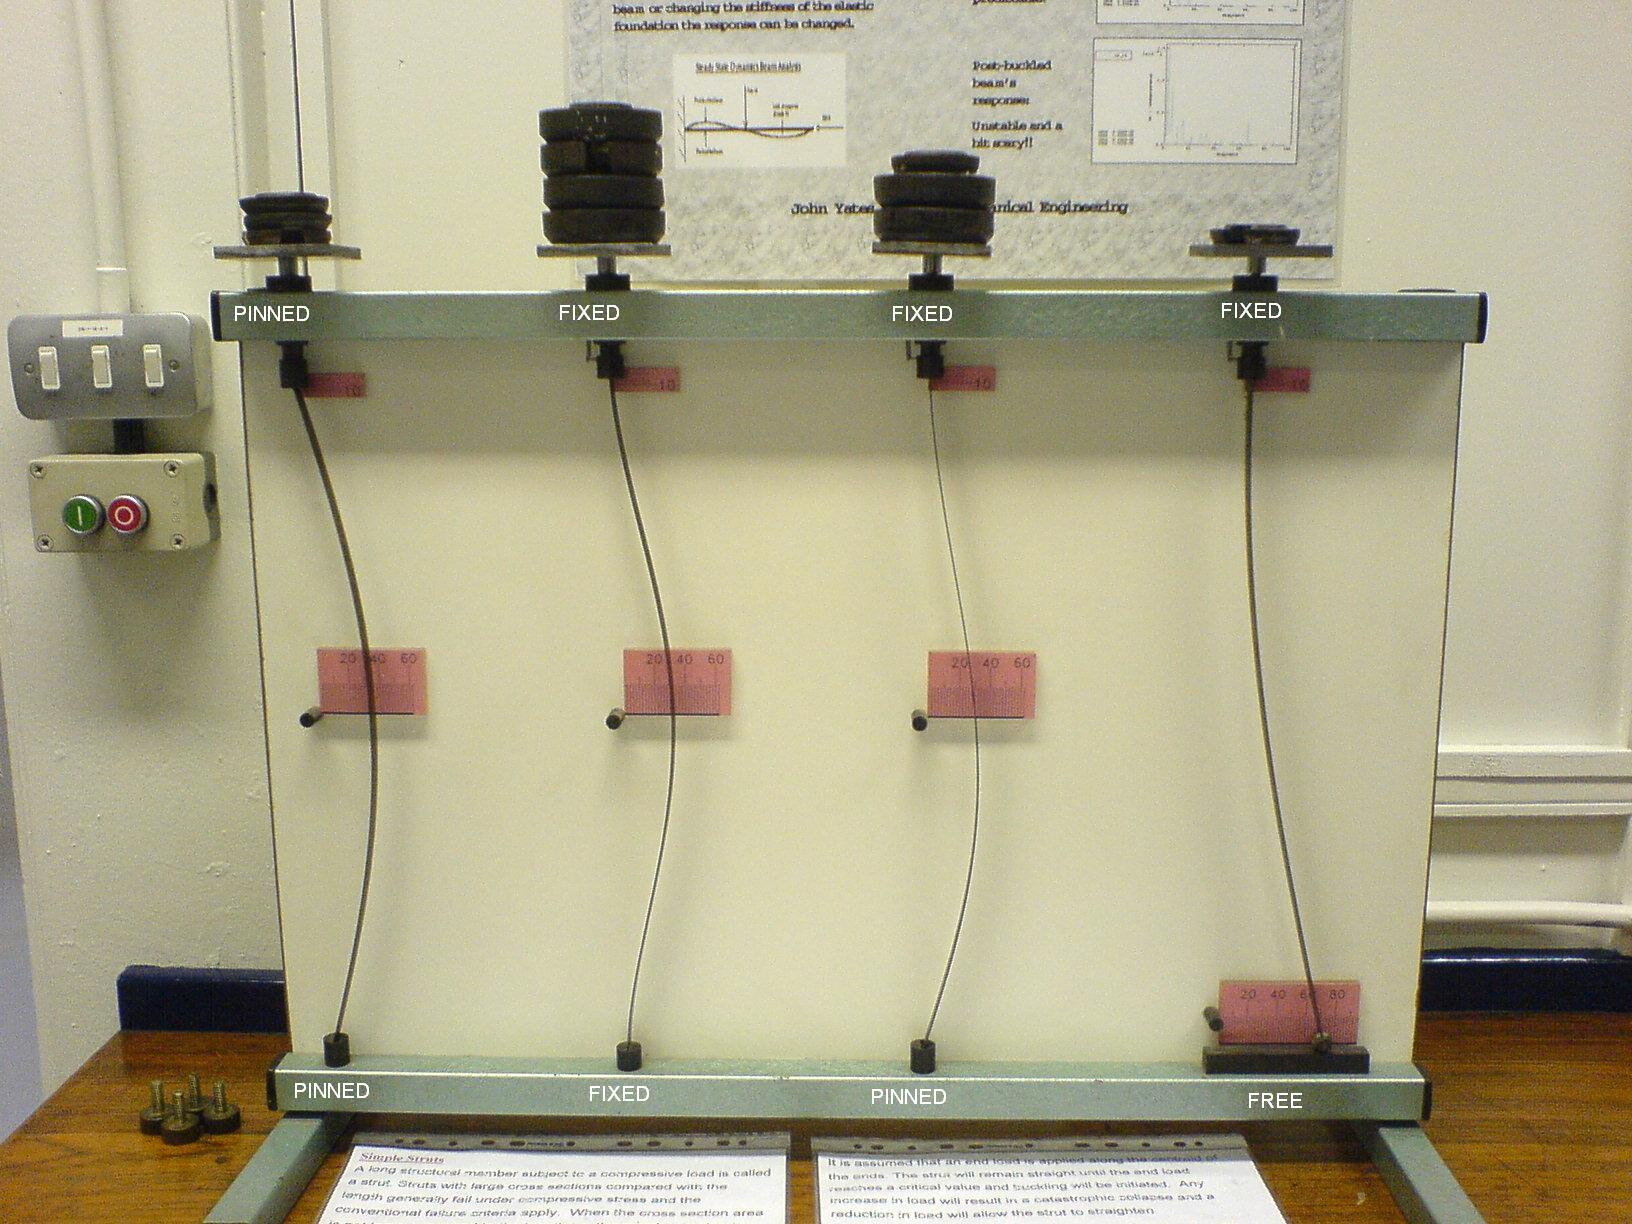
## Contexto físico

Cuando una columna es sometida a una carga axial de compresión $P$, puede permanecer recta mientras la carga sea pequeña.  
Sin embargo, a partir de cierto valor crítico, la configuración recta deja de ser estable y aparece una deflexión lateral.  
Ese fenómeno se conoce como **pandeo**.

Para una columna articulada en ambos extremos, el modelo lineal clásico conduce a la ecuación diferencial:

$EI \, \dfrac{d^2 y}{dx^2} + P\, y = 0$

donde:

- $y(x)$ es la deflexión lateral,
- $E$ es el módulo de elasticidad,
- $I$ es el momento de inercia de la sección transversal,
- $P$ es la carga axial de compresión,
- $x \in [0,L]$ es la coordenada axial.

Las condiciones de frontera para una columna **articulada-articulada** son:

$y(0)=0, \qquad y(L)=0$

## Solución analítica

Si se define

$\lambda^2 = \dfrac{P}{EI}$

entonces la ecuación queda:

$\dfrac{d^2 y}{dx^2} + \lambda^2 y = 0$

Su solución general es:

$y(x)=C_1 \sin(\lambda x) + C_2 \cos(\lambda x)$

Aplicando las condiciones de frontera:

- de $y(0)=0$ se obtiene $C_2=0$,
- de $y(L)=0$ se obtiene $\sin(\lambda L)=0$.

Por tanto,

$\lambda_n = \dfrac{n\pi}{L}, \qquad n=1,2,3,\dots$

y las cargas críticas son:

$P_n = EI \left(\dfrac{n\pi}{L}\right)^2$

La primera carga crítica, que es la más importante en ingeniería, es:

$P_{\mathrm{cr}} = EI \dfrac{\pi^2}{L^2}$

La forma modal fundamental es:

$y_1(x)=A\sin\left(\dfrac{\pi x}{L}\right)$

## Aproximación por diferencias finitas

Se divide el intervalo $[0,L]$ en $N+1$ subintervalos uniformes de tamaño:

$h=\dfrac{L}{N+1}$

Tomando los nodos interiores $x_i=ih$, con $i=1,2,\dots,N$, se aproxima la segunda derivada mediante la fórmula centrada:

$\dfrac{d^2 y}{dx^2}\bigg|_{x_i} \approx \dfrac{y_{i-1}-2y_i+y_{i+1}}{h^2}$

Al sustituir en la ecuación diferencial se obtiene:

$\dfrac{y_{i-1}-2y_i+y_{i+1}}{h^2} + \dfrac{P}{EI} y_i = 0$

Reordenando:

$-\dfrac{1}{h^2}y_{i-1} + \dfrac{2}{h^2}y_i - \dfrac{1}{h^2}y_{i+1}
= \dfrac{P}{EI} y_i$

Esto conduce al problema matricial de autovalores:

$\mathbf{A}\mathbf{y} = \mu \mathbf{y}$

donde:

$\mu = \dfrac{P}{EI}$

y $\mathbf{A}$ es la matriz tridiagonal:

$\mathbf{A} =
\begin{bmatrix}
\frac{2}{h^2} & -\frac{1}{h^2} & 0 & \cdots & 0 \\
-\frac{1}{h^2} & \frac{2}{h^2} & -\frac{1}{h^2} & \cdots & 0 \\
0 & -\frac{1}{h^2} & \frac{2}{h^2} & \ddots & 0 \\
\vdots & \vdots & \ddots & \ddots & -\frac{1}{h^2} \\
0 & 0 & 0 & -\frac{1}{h^2} & \frac{2}{h^2}
\end{bmatrix}$

Una vez hallado el menor autovalor $\mu_1$, la carga crítica aproximada es:

$P_{\mathrm{cr}}^{(DF)} = EI \, \mu_1$

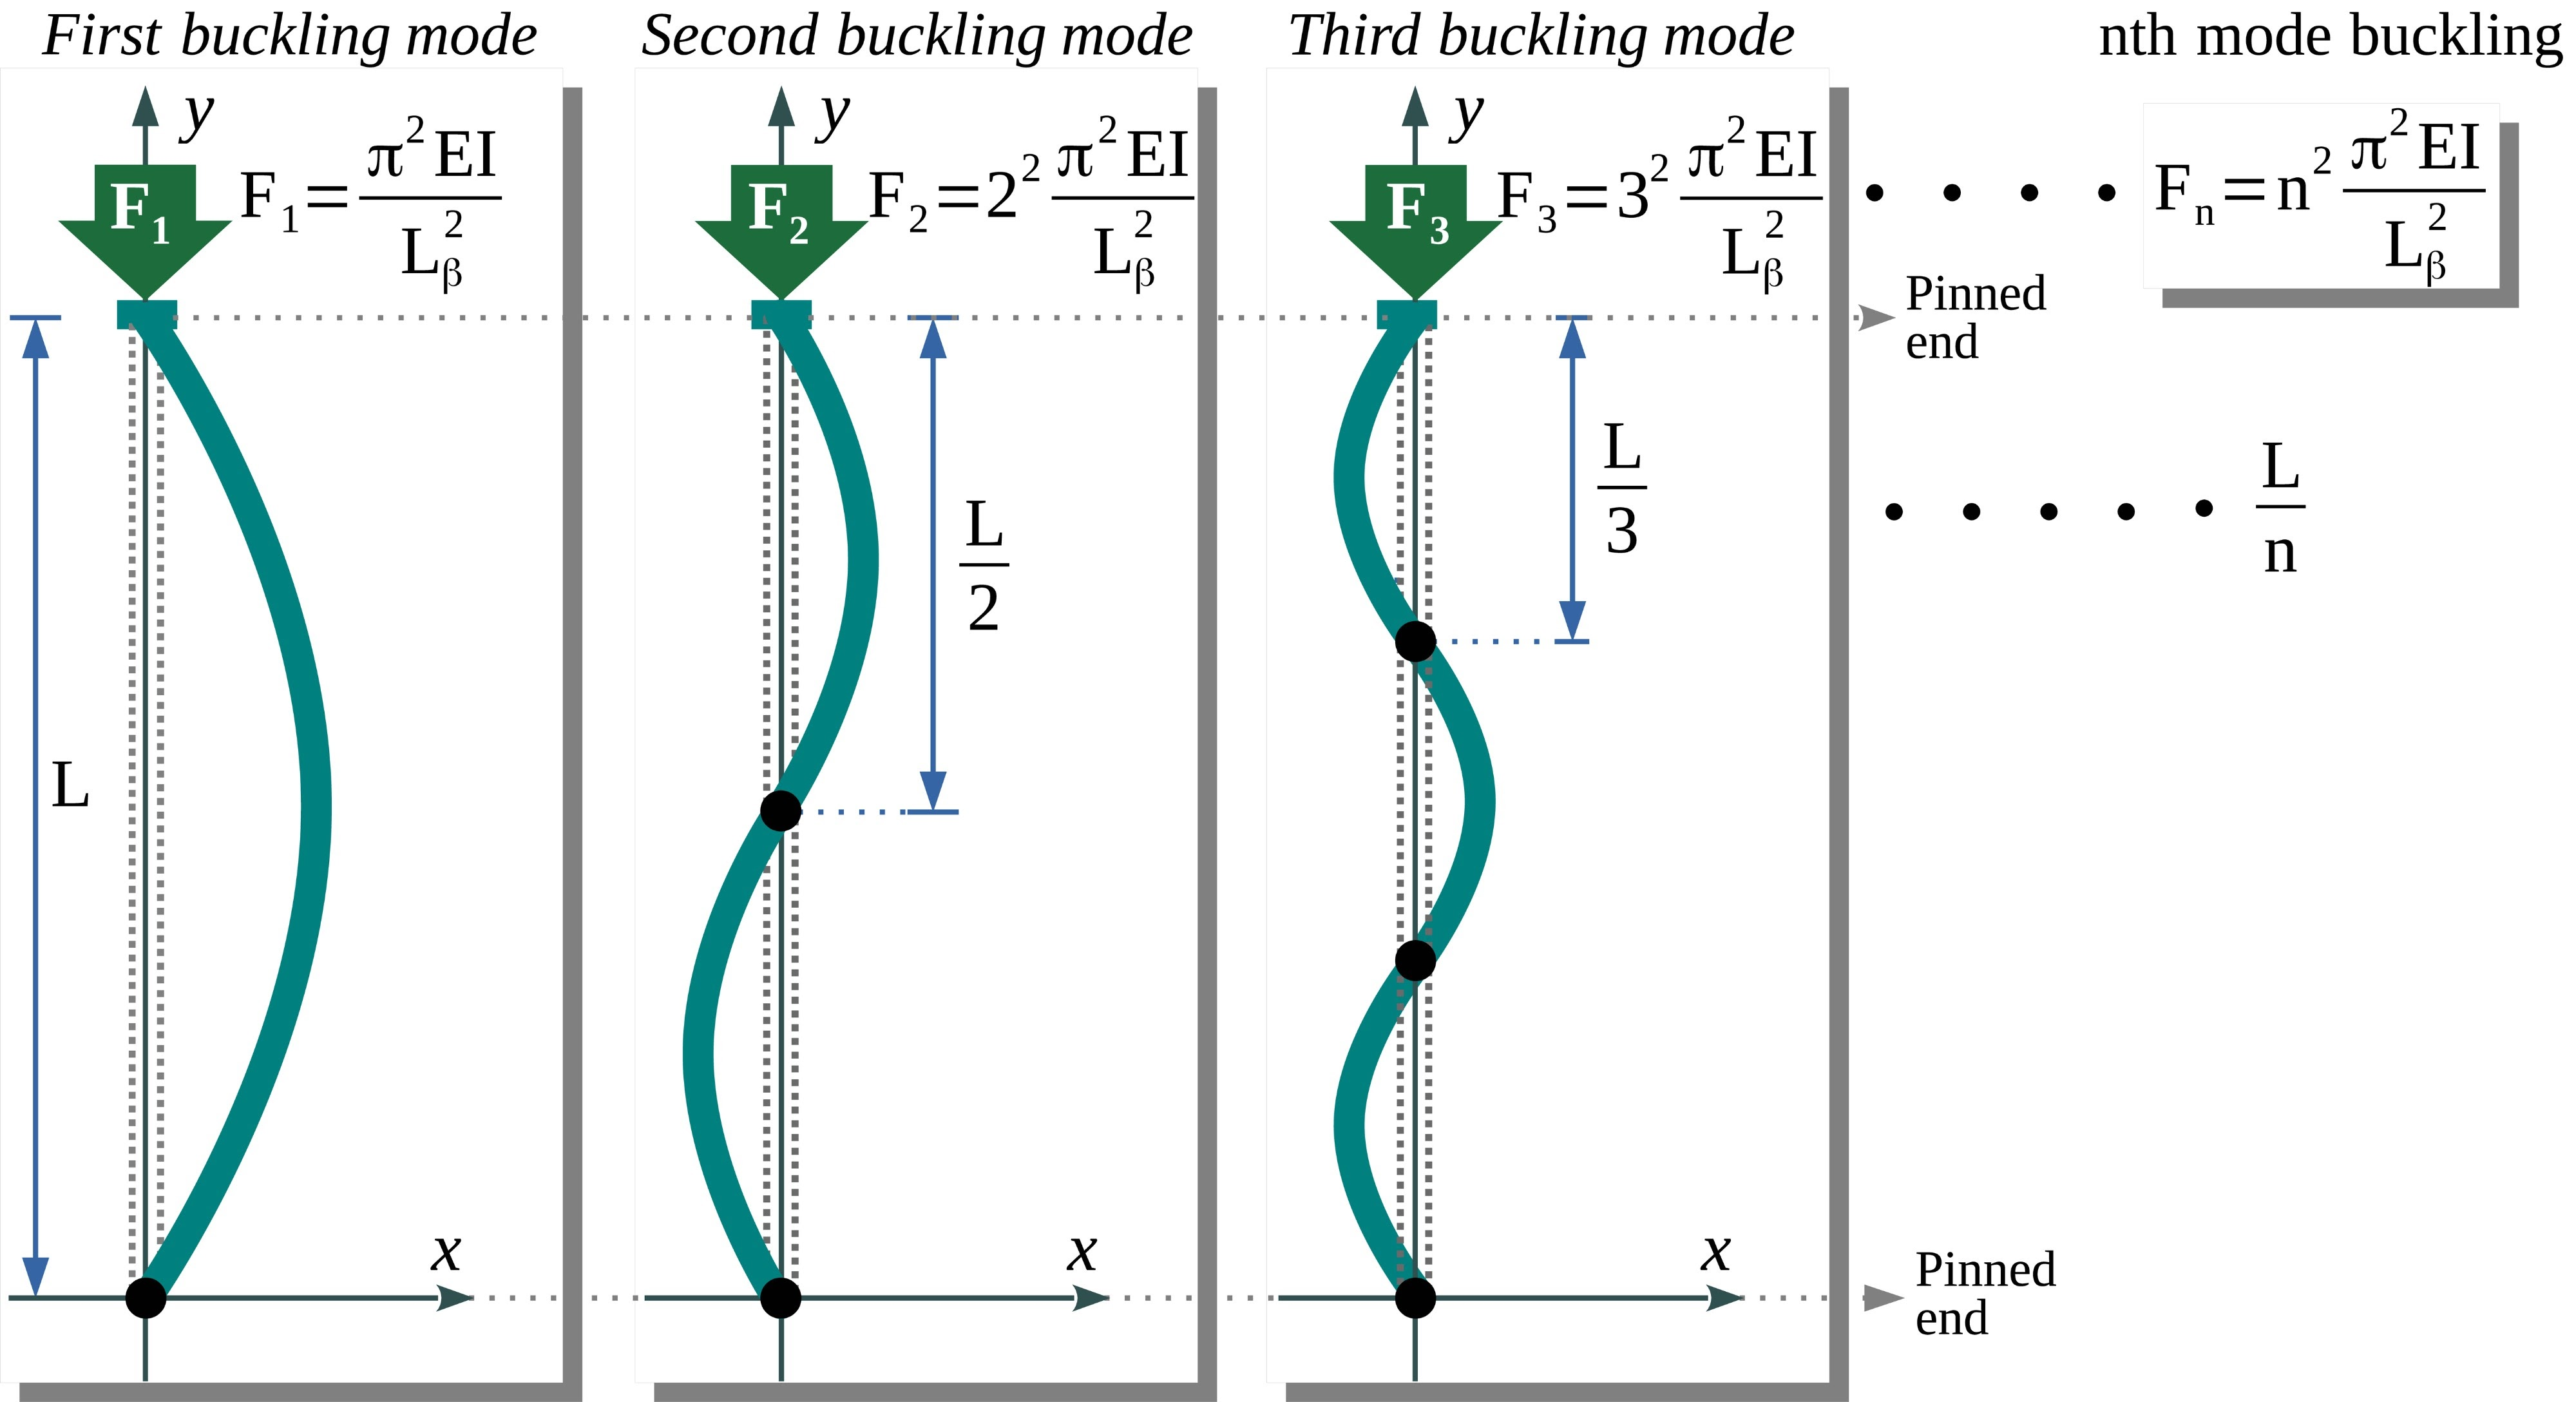

## Qué hace la celda de código

La única celda de código de este notebook:

1. Define los parámetros físicos de la columna.
2. Construye la matriz de diferencias finitas.
3. Resuelve el problema de autovalores.
4. Calcula la carga crítica numérica.
5. Compara con la carga crítica analítica de Euler.
6. Grafica la forma modal obtenida numéricamente y la compara con la solución exacta.
7. Muestra figuras representativas del fenómeno de pandeo.


Pandeo de una columna 1D por diferencias finitas
Longitud L                  = 2.0000 m
Módulo E                    = 2.1000e+11 Pa
Momento de inercia I        = 8.0000e-06 m^4
Número de nodos interiores  = 40
Tamaño de paso h            = 0.048780 m
----------------------------------------------------------------------
Carga crítica exacta Euler  = 4.145234e+06 N
Carga crítica numérica DF   = 4.143206e+06 N
Error relativo              = 0.048918 %
----------------------------------------------------------------------
Primeros 4 valores críticos aproximados:
Modo 1:  P_DF = 4.143206e+06 N   |   P_exacta = 4.145234e+06 N   |   error = 0.048918 %
Modo 2:  P_DF = 1.654851e+07 N   |   P_exacta = 1.658094e+07 N   |   error = 0.195556 %
Modo 3:  P_DF = 3.714311e+07 N   |   P_exacta = 3.730710e+07 N   |   error = 0.439570 %
Modo 4:  P_DF = 6.580616e+07 N   |   P_exacta = 6.632374e+07 N   |   error = 0.780389 %


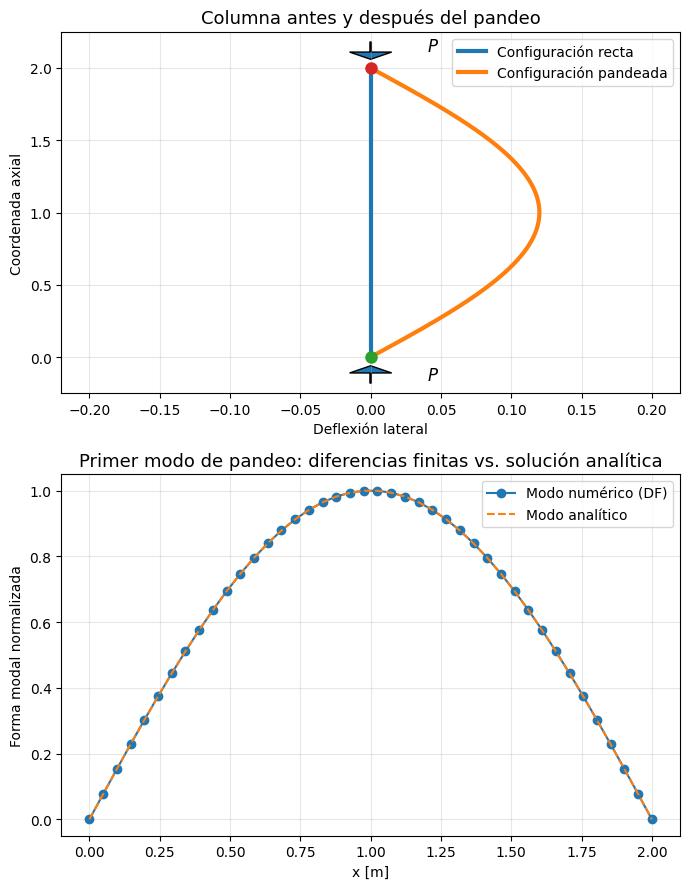

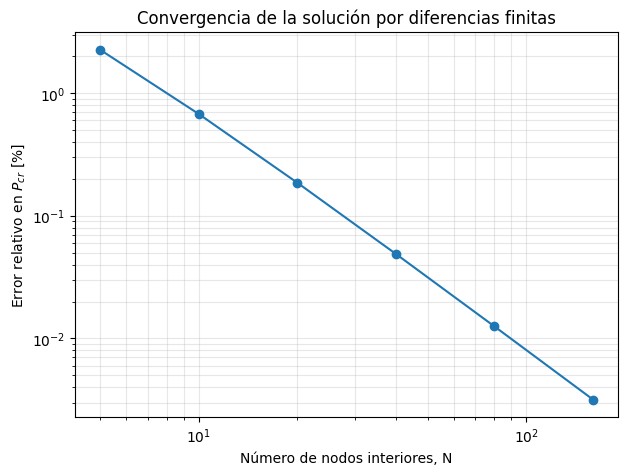


Interpretación:
La menor carga crítica corresponde al primer modo de pandeo.
Al aumentar el número de nodos interiores, la aproximación por diferencias finitas converge a la solución exacta de Euler.
Este ejemplo muestra cómo un problema de estabilidad estructural puede convertirse en un problema matricial de autovalores.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PROBLEMA: PANDEO DE UNA COLUMNA 1D ARTICULADA-ARTICULADA
# ============================================================

# ----------------------------
# 1. Parámetros físicos
# ----------------------------
L = 2.0             # Longitud de la columna [m]
E = 210e9           # Módulo de elasticidad [Pa]
I = 8.0e-6          # Momento de inercia [m^4]
N = 40              # Número de nodos interiores

# Tamaño de paso
h = L / (N + 1)

# ----------------------------
# 2. Construcción de la matriz de diferencias finitas
#    A y = mu y, donde mu = P/(EI)
# ----------------------------
diag = 2.0 * np.ones(N) / h**2
off  = -1.0 * np.ones(N - 1) / h**2

A = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)

# ----------------------------
# 3. Resolución del problema de autovalores
# ----------------------------
eigvals, eigvecs = np.linalg.eigh(A)

# Ordenar por magnitud creciente
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Primer autovalor y primer modo
mu1 = eigvals[0]
phi1 = eigvecs[:, 0]

# Carga crítica numérica
Pcr_num = E * I * mu1

# ----------------------------
# 4. Solución analítica de Euler
# ----------------------------
Pcr_exact = (np.pi**2) * E * I / L**2

# Nodos interiores y nodos completos
x_int = np.linspace(h, L - h, N)
x_full = np.linspace(0, L, N + 2)

# Insertar condiciones de frontera
phi1_full = np.zeros(N + 2)
phi1_full[1:-1] = phi1

# Normalización del modo numérico
phi1_full = phi1_full / np.max(np.abs(phi1_full))

# Solución analítica del primer modo
mode_exact = np.sin(np.pi * x_full / L)
mode_exact = mode_exact / np.max(np.abs(mode_exact))

# Ajustar el signo para que ambas curvas tengan la misma orientación visual
if np.dot(phi1_full, mode_exact) < 0:
    phi1_full = -phi1_full

# Error relativo
error_rel = abs(Pcr_num - Pcr_exact) / Pcr_exact * 100

# ----------------------------
# 5. Mostrar resultados numéricos
# ----------------------------
print("="*70)
print("Pandeo de una columna 1D por diferencias finitas")
print("="*70)
print(f"Longitud L                  = {L:.4f} m")
print(f"Módulo E                    = {E:.4e} Pa")
print(f"Momento de inercia I        = {I:.4e} m^4")
print(f"Número de nodos interiores  = {N}")
print(f"Tamaño de paso h            = {h:.6f} m")
print("-"*70)
print(f"Carga crítica exacta Euler  = {Pcr_exact:.6e} N")
print(f"Carga crítica numérica DF   = {Pcr_num:.6e} N")
print(f"Error relativo              = {error_rel:.6f} %")
print("-"*70)
print("Primeros 4 valores críticos aproximados:")
for k in range(4):
    Pk = E * I * eigvals[k]
    Pk_exact = E * I * (k + 1)**2 * np.pi**2 / L**2
    errk = abs(Pk - Pk_exact) / Pk_exact * 100
    print(f"Modo {k+1}:  P_DF = {Pk:.6e} N   |   P_exacta = {Pk_exact:.6e} N   |   error = {errk:.6f} %")
print("="*70)

# ----------------------------
# 6. Figura 1: esquema físico del fenómeno
# ----------------------------
fig = plt.figure(figsize=(7, 9))

ax1 = fig.add_subplot(2, 1, 1)
ax1.set_title("Columna antes y después del pandeo", fontsize=13)

# Columna recta
ax1.plot([0, 0], [0, L], linewidth=3, label="Configuración recta")

# Columna pandeada esquemática
y_plot = np.linspace(0, L, 400)
x_buckled = 0.12 * np.sin(np.pi * y_plot / L)
ax1.plot(x_buckled, y_plot, linewidth=3, label="Configuración pandeada")

# Soportes articulados
ax1.plot(0, 0, marker='o', markersize=8)
ax1.plot(0, L, marker='o', markersize=8)

# Flechas de compresión
ax1.arrow(0, L + 0.18, 0, -0.12, head_width=0.03, head_length=0.05, length_includes_head=True)
ax1.arrow(0, -0.18, 0, 0.12, head_width=0.03, head_length=0.05, length_includes_head=True)
ax1.text(0.04, L + 0.12, "$P$", fontsize=12)
ax1.text(0.04, -0.16, "$P$", fontsize=12)

ax1.set_xlabel("Deflexión lateral")
ax1.set_ylabel("Coordenada axial")
ax1.set_xlim(-0.22, 0.22)
ax1.set_ylim(-0.25, L + 0.25)
ax1.grid(True, alpha=0.3)
ax1.legend()

# ----------------------------
# 7. Figura 2: modo numérico vs analítico
# ----------------------------
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_title("Primer modo de pandeo: diferencias finitas vs. solución analítica", fontsize=13)
ax2.plot(x_full, phi1_full, "o-", label="Modo numérico (DF)")
ax2.plot(x_full, mode_exact, "--", label="Modo analítico")
ax2.set_xlabel("x [m]")
ax2.set_ylabel("Forma modal normalizada")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# 8. Figura 3: influencia del número de nodos en la convergencia
# ----------------------------
N_values = [5, 10, 20, 40, 80, 160]
errors = []
P_values = []

for Ntest in N_values:
    htest = L / (Ntest + 1)
    diag = 2.0 * np.ones(Ntest) / htest**2
    off  = -1.0 * np.ones(Ntest - 1) / htest**2
    Atest = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    vals, _ = np.linalg.eigh(Atest)
    Ptest = E * I * np.min(vals)
    P_values.append(Ptest)
    errors.append(abs(Ptest - Pcr_exact) / Pcr_exact * 100)

plt.figure(figsize=(7, 5))
plt.plot(N_values, errors, "o-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Número de nodos interiores, N")
plt.ylabel("Error relativo en $P_{cr}$ [%]")
plt.title("Convergencia de la solución por diferencias finitas")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# ----------------------------
# 9. Comentario final
# ----------------------------
print("\nInterpretación:")
print("La menor carga crítica corresponde al primer modo de pandeo.")
print("Al aumentar el número de nodos interiores, la aproximación por diferencias finitas converge a la solución exacta de Euler.")
print("Este ejemplo muestra cómo un problema de estabilidad estructural puede convertirse en un problema matricial de autovalores.")



## Comentarios didácticos finales

1. El problema de pandeo lineal se transforma en un **problema de autovalores**.
2. La carga crítica de pandeo corresponde al **menor autovalor** del sistema discreto multiplicado por $EI$.
3. La forma de pandeo obtenida es el **autovector asociado**.
4. Este ejemplo permite discutir con los estudiantes:
   - discretización de derivadas,
   - interpretación física de autovalores y autovectores,
   - convergencia numérica,
   - comparación entre solución analítica y solución aproximada.

## Posibles extensiones para clase

- Cambiar las condiciones de frontera y estudiar otros apoyos.
- Introducir una carga lateral distribuida adicional.
- Resolver el problema de una columna con rigidez variable $EI(x)$.
- Comparar diferencias finitas con elementos finitos.

